In [1]:
EN_COLAB = False

if EN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    RUTA_BASE = '/content/drive/MyDrive/Proyecto_UJIIndoorLoc/'
else:
    RUTA_BASE = './'

RUTA_DATOS = RUTA_BASE + 'data/'
RUTA_MODELOS = RUTA_BASE + 'models/'
RUTA_FIGURAS = RUTA_BASE + 'figuras/'

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn import preprocessing
import phik
from phik.report import plot_correlation_matrix

# Localizacion WiFi indoor (UJIIndoorLoc) - EDA y preprocesamiento

Queremos predecir en que edificio y piso esta un celular a partir de la intensidad de 520 senales WiFi que detecta. En este notebook cargamos los datos, hacemos un analisis exploratorio, creamos la variable objetivo BF y dejamos todo limpio y codificado para los siguientes notebooks.

Dataset: UJIIndoorLoc (UCI, id 310), de la Universitat Jaume I.

## Cargar los datos

In [3]:
train = pd.read_csv(RUTA_DATOS + 'trainingData.csv')
test = pd.read_csv(RUTA_DATOS + 'validationData.csv')

print(train.shape, test.shape)
train.head()

(19937, 529) (1111, 529)


,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP520,LONGITUDE,LATITUDE,FLOOR,BUILDINGID,SPACEID,RELATIVEPOSITION,USERID,PHONEID,TIMESTAMP
0,100,100,100,100,100,100,100,100,100,100,...,100,-7541.2643,4.864921e+06,2,1,106,2,2,23,1371713733
1,100,100,100,100,100,100,100,100,100,100,...,100,-7536.6212,4.864934e+06,2,1,106,2,2,23,1371713691
2,100,100,100,100,100,100,100,-97,100,100,...,100,-7519.1524,4.864950e+06,2,1,103,2,2,23,1371714095
3,100,100,100,100,100,100,100,100,100,100,...,100,-7524.5704,4.864934e+06,2,1,102,2,2,23,1371713807
4,100,100,100,100,100,100,100,100,100,100,...,100,-7632.1436,4.864982e+06,0,0,122,2,11,13,1369909710


In [4]:
print('Nulos en train:', train.isnull().sum().sum())
print('Nulos en test:', test.isnull().sum().sum())

Nulos en train: 0
Nulos en test: 0


Confirmamos que los dos archivos tienen 529 columnas y que no hay valores nulos. Las primeras 520 columnas son las senales WAP y las ultimas 9 son los metadatos.

## Separar columnas de senal y metadatos

In [5]:
cols_wap = []
for col in train.columns:
    if col.startswith('WAP'):
        cols_wap.append(col)

cols_meta = ['LONGITUDE', 'LATITUDE', 'FLOOR', 'BUILDINGID', 'SPACEID',
             'RELATIVEPOSITION', 'USERID', 'PHONEID', 'TIMESTAMP']
print(len(cols_wap))
train[cols_meta].describe()

520


,LONGITUDE,LATITUDE,FLOOR,BUILDINGID,SPACEID,RELATIVEPOSITION,USERID,PHONEID,TIMESTAMP
count,19937.000000,1.993700e+04,19937.000000,19937.000000,19937.000000,19937.000000,19937.000000,19937.000000,1.993700e+04
mean,-7464.275947,4.864871e+06,1.674575,1.212820,148.429954,1.833024,9.068014,13.021869,1.371421e+09
std,123.402010,6.693318e+01,1.223078,0.833139,58.342106,0.372964,4.988720,5.362410,5.572054e+05
min,-7691.338400,4.864746e+06,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.369909e+09
25%,-7594.737000,4.864821e+06,1.000000,0.000000,110.000000,2.000000,5.000000,8.000000,1.371056e+09
50%,-7423.060900,4.864852e+06,2.000000,1.000000,129.000000,2.000000,11.000000,13.000000,1.371716e+09
75%,-7359.193000,4.864930e+06,3.000000,2.000000,207.000000,2.000000,13.000000,14.000000,1.371721e+09
max,-7300.818990,4.865017e+06,4.000000,2.000000,254.000000,2.000000,18.000000,24.000000,1.371738e+09


## Variable objetivo: BF

Combinamos BUILDINGID y FLOOR en una sola etiqueta, por ejemplo 'B0_P2' quiere decir edificio 0, piso 2.

In [6]:
train['BF'] = 'B' + train['BUILDINGID'].astype(str) + '_P' + train['FLOOR'].astype(str)
test['BF'] = 'B' + test['BUILDINGID'].astype(str) + '_P' + test['FLOOR'].astype(str)

print(train['BF'].value_counts().sort_index())
print(test['BF'].value_counts().sort_index())

BF
B0_P0    1059
B0_P1    1356
B0_P2    1443
B0_P3    1391
B1_P0    1368
B1_P1    1484
B1_P2    1396
B1_P3     948
B2_P0    1942
B2_P1    2162
B2_P2    1577
B2_P3    2709
B2_P4    1102
Name: count, dtype: int64
BF
B0_P0     78
B0_P1    208
B0_P2    165
B0_P3     85
B1_P0     30
B1_P1    143
B1_P2     87
B1_P3     47
B2_P0     24
B2_P1    111
B2_P2     54
B2_P3     40
B2_P4     39
Name: count, dtype: int64


C:\Users\pc\AppData\Local\Temp\ipykernel_21808\5991129.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['BF'] = 'B' + train['BUILDINGID'].astype(str) + '_P' + train['FLOOR'].astype(str)
C:\Users\pc\AppData\Local\Temp\ipykernel_21808\5991129.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['BF'] = 'B' + test['BUILDINGID'].astype(str) + '_P' + test['FLOOR'].astype(str)


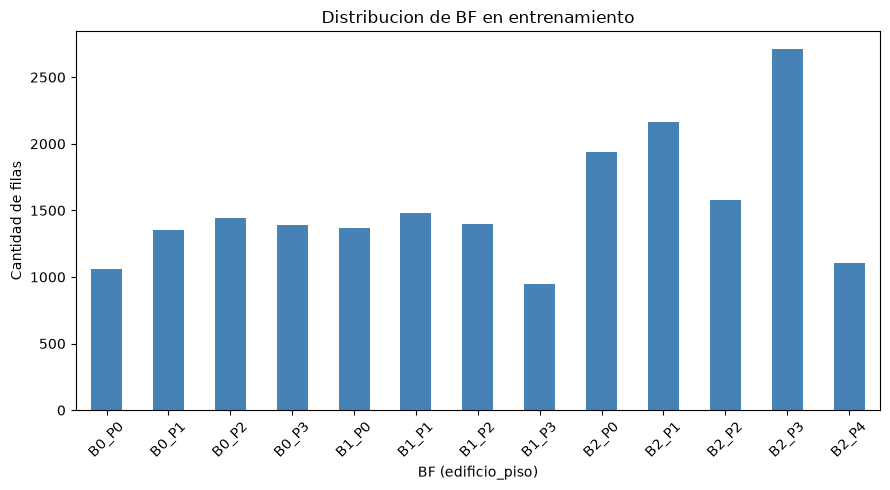

In [7]:
plt.figure(figsize=(9, 5))
train['BF'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.xlabel('BF (edificio_piso)')
plt.ylabel('Cantidad de filas')
plt.title('Distribucion de BF en entrenamiento')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + 'distribucion_bf_train.png')
plt.show()

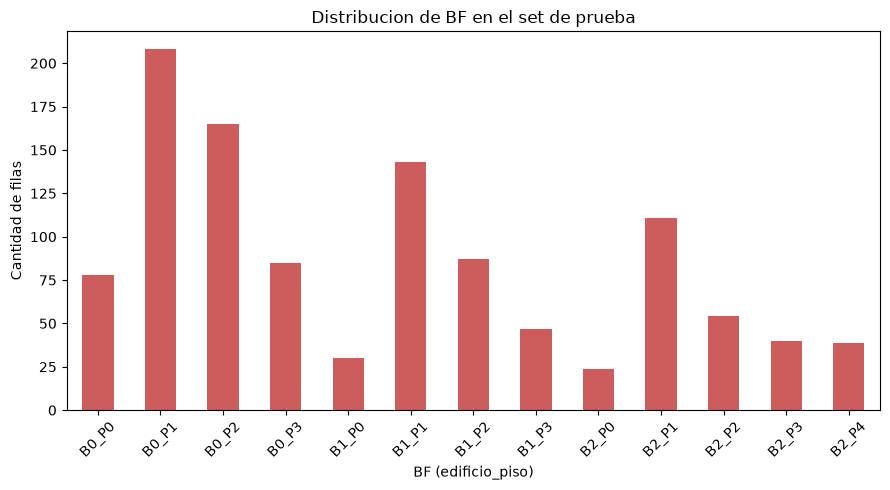

In [8]:
plt.figure(figsize=(9, 5))
test['BF'].value_counts().sort_index().plot(kind='bar', color='indianred')
plt.xlabel('BF (edificio_piso)')
plt.ylabel('Cantidad de filas')
plt.title('Distribucion de BF en el set de prueba')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + 'distribucion_bf_test.png')
plt.show()

In [9]:
clases_train = set(train['BF'].unique())
clases_test = set(test['BF'].unique())

faltantes = []
for clase in clases_test:
    if clase not in clases_train:
        faltantes.append(clase)

print('Cantidad de clases en train:', len(clases_train))
print('Cantidad de clases en test:', len(clases_test))
print('Clases en test que no estan en train:', faltantes)

Cantidad de clases en train: 13
Cantidad de clases en test: 13
Clases en test que no estan en train: []


Nos salieron las 13 clases que esperabamos: los edificios 0 y 1 con pisos 0 a 3, y el edificio 2 con pisos 0 a 4. Todas las clases de test aparecen en train, asi que podemos seguir. Las clases estan desbalanceadas: la que mas filas tiene es B2_P3 (piso 3 del edificio 2) y la que menos tiene es B1_P3.

## Mapa de los puntos de medicion

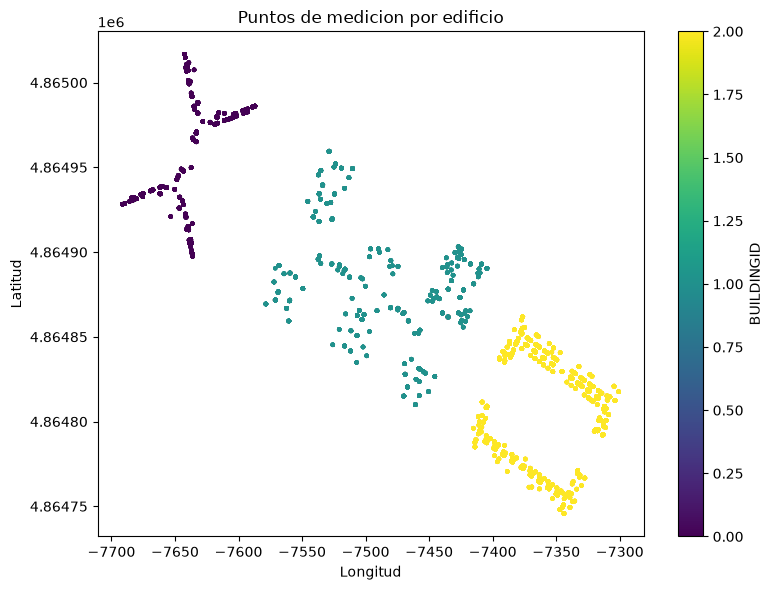

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(train['LONGITUDE'], train['LATITUDE'], c=train['BUILDINGID'], cmap='viridis', s=5)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Puntos de medicion por edificio')
plt.colorbar(label='BUILDINGID')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + 'mapa_edificios.png')
plt.show()

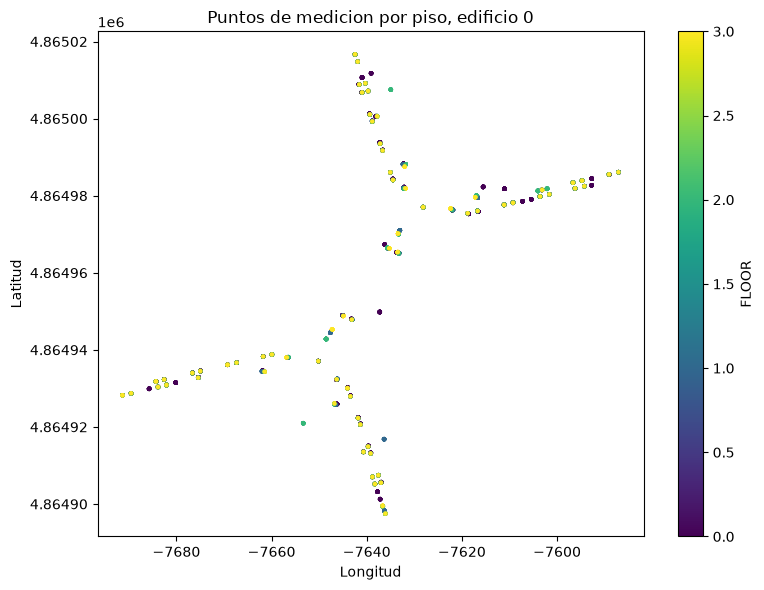

In [11]:
train_b0 = train[train['BUILDINGID'] == 0]

plt.figure(figsize=(8, 6))
plt.scatter(train_b0['LONGITUDE'], train_b0['LATITUDE'], c=train_b0['FLOOR'], cmap='viridis', s=5)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Puntos de medicion por piso, edificio 0')
plt.colorbar(label='FLOOR')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + 'mapa_pisos_edificio0.png')
plt.show()

Por edificio los puntos se separan bastante bien, como se esperaba. Por piso dentro de un mismo edificio se mezclan mas, porque los pisos quedan uno encima del otro en la misma posicion (x, y).

## Analisis del valor 100 (no detectado)

El valor 100 en las columnas WAP no es una senal real, significa que ese punto de acceso no se detecto desde ahi.

In [12]:
porcentaje_100 = (train[cols_wap] == 100).sum().sum() / train[cols_wap].size
print('Porcentaje de celdas con 100:', porcentaje_100)

Porcentaje de celdas con 100: 0.965394550526466


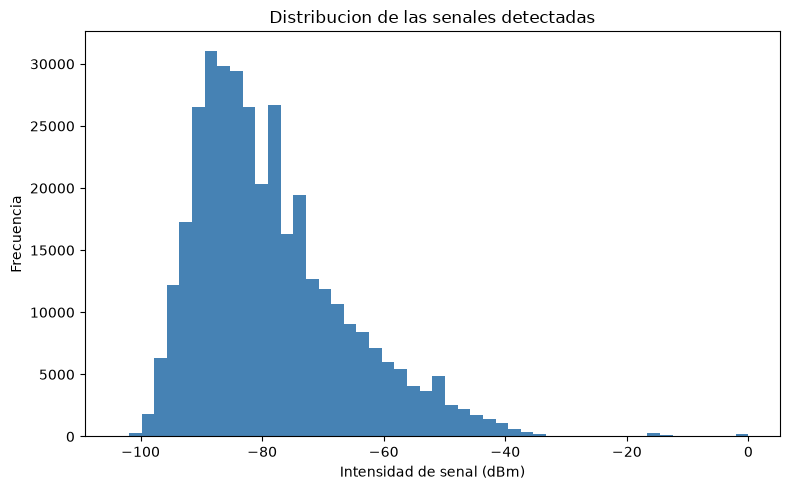

Minimo: -104 Maximo: 0


In [13]:
valores_detectados = train[cols_wap].values.flatten()
valores_detectados = valores_detectados[valores_detectados != 100]

plt.figure(figsize=(8, 5))
plt.hist(valores_detectados, bins=50, color='steelblue')
plt.xlabel('Intensidad de senal (dBm)')
plt.ylabel('Frecuencia')
plt.title('Distribucion de las senales detectadas')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + 'histograma_senales_detectadas.png')
plt.show()

print('Minimo:', valores_detectados.min(), 'Maximo:', valores_detectados.max())

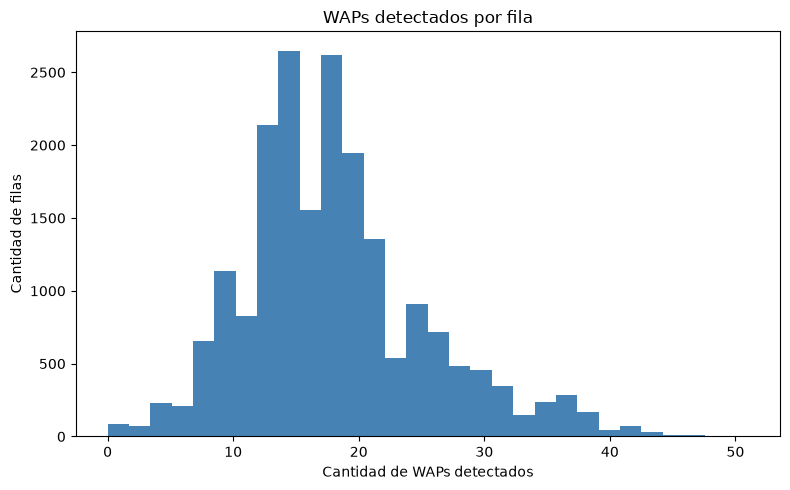

Filas sin ninguna deteccion: 76


In [14]:
detecciones_por_fila = (train[cols_wap] != 100).sum(axis=1)

plt.figure(figsize=(8, 5))
plt.hist(detecciones_por_fila, bins=30, color='steelblue')
plt.xlabel('Cantidad de WAPs detectados')
plt.ylabel('Cantidad de filas')
plt.title('WAPs detectados por fila')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + 'detecciones_por_fila.png')
plt.show()

filas_sin_deteccion = (detecciones_por_fila == 0).sum()
print('Filas sin ninguna deteccion:', filas_sin_deteccion)

In [15]:
waps_inutiles_train = []
for col in cols_wap:
    if (train[col] == 100).all():
        waps_inutiles_train.append(col)

waps_inutiles_test = []
for col in cols_wap:
    if (test[col] == 100).all():
        waps_inutiles_test.append(col)

print('WAPs nunca detectados en train:', len(waps_inutiles_train))
print('WAPs nunca detectados en test:', len(waps_inutiles_test))

WAPs nunca detectados en train: 55
WAPs nunca detectados en test: 153


Casi toda la matriz de senales esta vacia, como esperabamos. Las senales que si se detectan van de -104 a 0 dBm, dentro del rango que dice el dataset. Hay varios WAPs que nunca se detectan ni en train ni en test; los anotamos para tenerlos en cuenta en el notebook 02.

## Duplicados

In [16]:
duplicados = train.duplicated().sum()
print('Filas duplicadas:', duplicados)

train = train.drop_duplicates()
print('Forma de train despues de quitar duplicados:', train.shape)

Filas duplicadas: 637


Forma de train despues de quitar duplicados: (19300, 530)


Quitamos las filas duplicadas de train. En test no tocamos nada, porque es la prueba final y debe quedar tal cual viene.

## Correlacion

phik sobre las 520 columnas WAP no es practico, asi que lo hacemos en dos partes: los metadatos contra BF con phik, y un mapa de calor normal con los WAPs que mas se detectan.

interval columns not set, guessing: ['LONGITUDE', 'LATITUDE', 'FLOOR', 'BUILDINGID', 'SPACEID', 'RELATIVEPOSITION', 'USERID', 'PHONEID', 'TIMESTAMP']


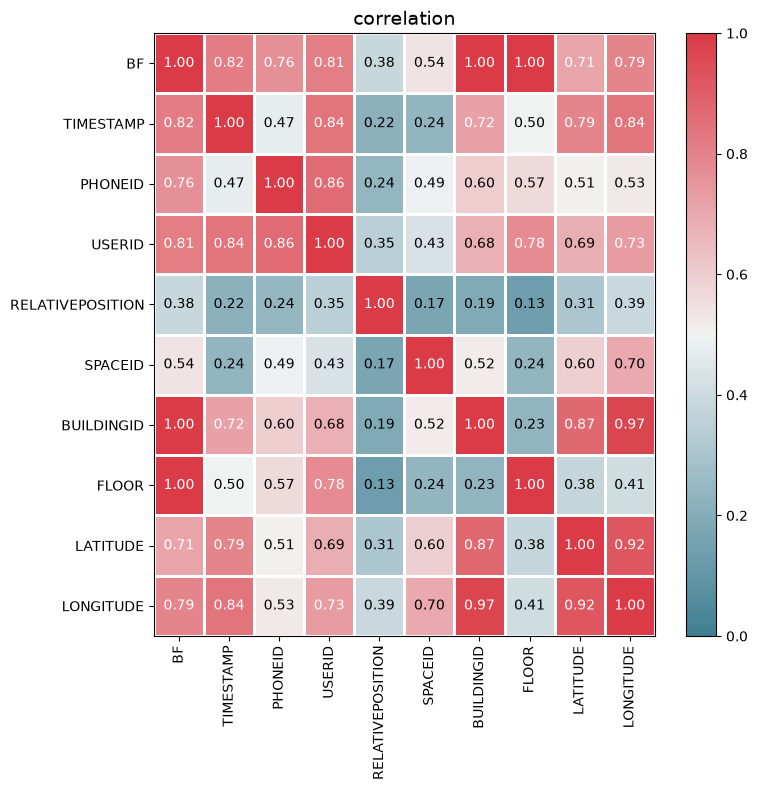

In [17]:
datos_phik = train[cols_meta + ['BF']]

coerr_mat = datos_phik.phik_matrix()
cmap = sns.diverging_palette(220, 10, as_cmap=True)

plot_correlation_matrix(coerr_mat.values, x_labels=coerr_mat.columns, y_labels=coerr_mat.index,
                        vmin=0, vmax=1, color_map=cmap, figsize=(8, 8))
plt.savefig(RUTA_FIGURAS + 'correlacion_phik_metadatos.png')
plt.show()

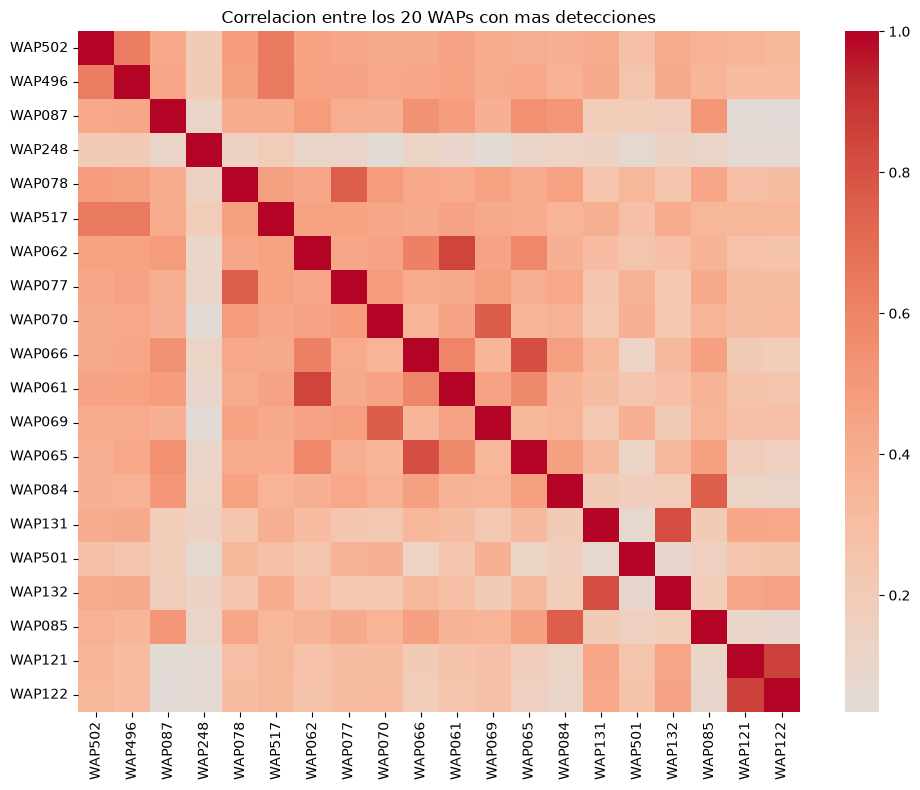

In [18]:
num_detecciones = (train[cols_wap] != 100).sum().sort_values(ascending=False)
top20_waps = num_detecciones.head(20).index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(train[top20_waps].corr(), cmap='coolwarm', center=0)
plt.title('Correlacion entre los 20 WAPs con mas detecciones')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + 'correlacion_top20_waps.png')
plt.show()

Con phik se ve que BUILDINGID, FLOOR y la ubicacion (LONGITUDE, LATITUDE) estan fuertemente relacionados con BF, lo cual tiene sentido porque BF se construye a partir de esos mismos datos. USERID y PHONEID tambien se relacionan con la ubicacion, porque cada usuario midio en zonas especificas. Entre los WAPs mas detectados hay algunas correlaciones altas, de puntos de acceso que probablemente estan cerca unos de otros.

## Transformar el valor 100

El 100 no es una senal, es "no detectado". Si lo dejamos asi, el modelo lo va a interpretar como la senal mas fuerte posible (mas fuerte que 0 dBm), lo cual es al reves de la realidad. Por eso lo cambiamos por -105, un valor apenas por debajo de la senal real mas debil.

In [19]:
train[cols_wap] = train[cols_wap].replace(100, -105)
test[cols_wap] = test[cols_wap].replace(100, -105)

In [20]:
detecciones_por_fila_train = (train[cols_wap] != -105).sum(axis=1)
filas_antes = train.shape[0]
train = train[detecciones_por_fila_train > 0]
filas_despues = train.shape[0]
print('Filas quitadas por no tener ninguna deteccion:', filas_antes - filas_despues)
print('Forma final de train:', train.shape)

Filas quitadas por no tener ninguna deteccion: 73
Forma final de train: (19227, 530)


En test no quitamos filas sin deteccion porque es la prueba final y debe quedar igual a como llega.

## Quitar columnas que no deben ser rasgos

USERID, PHONEID, TIMESTAMP, SPACEID y RELATIVEPOSITION no aportan nada al problema y se eliminan. LONGITUDE, LATITUDE, BUILDINGID y FLOOR se quedan guardadas en el CSV porque la app las va a usar para dibujar el mapa, pero nunca van a entrar como rasgos del modelo porque delatarian la respuesta.

In [21]:
cols_no_rasgos = ['USERID', 'PHONEID', 'TIMESTAMP', 'SPACEID', 'RELATIVEPOSITION']

train = train.drop(columns=cols_no_rasgos)
test = test.drop(columns=cols_no_rasgos)

print(train.columns.tolist())

['WAP001', 'WAP002', 'WAP003', 'WAP004', 'WAP005', 'WAP006', 'WAP007', 'WAP008', 'WAP009', 'WAP010', 'WAP011', 'WAP012', 'WAP013', 'WAP014', 'WAP015', 'WAP016', 'WAP017', 'WAP018', 'WAP019', 'WAP020', 'WAP021', 'WAP022', 'WAP023', 'WAP024', 'WAP025', 'WAP026', 'WAP027', 'WAP028', 'WAP029', 'WAP030', 'WAP031', 'WAP032', 'WAP033', 'WAP034', 'WAP035', 'WAP036', 'WAP037', 'WAP038', 'WAP039', 'WAP040', 'WAP041', 'WAP042', 'WAP043', 'WAP044', 'WAP045', 'WAP046', 'WAP047', 'WAP048', 'WAP049', 'WAP050', 'WAP051', 'WAP052', 'WAP053', 'WAP054', 'WAP055', 'WAP056', 'WAP057', 'WAP058', 'WAP059', 'WAP060', 'WAP061', 'WAP062', 'WAP063', 'WAP064', 'WAP065', 'WAP066', 'WAP067', 'WAP068', 'WAP069', 'WAP070', 'WAP071', 'WAP072', 'WAP073', 'WAP074', 'WAP075', 'WAP076', 'WAP077', 'WAP078', 'WAP079', 'WAP080', 'WAP081', 'WAP082', 'WAP083', 'WAP084', 'WAP085', 'WAP086', 'WAP087', 'WAP088', 'WAP089', 'WAP090', 'WAP091', 'WAP092', 'WAP093', 'WAP094', 'WAP095', 'WAP096', 'WAP097', 'WAP098', 'WAP099', 'WAP100',

## Codificar la variable objetivo

In [22]:
le = preprocessing.LabelEncoder()
le.fit(train['BF'])
print(le.classes_)

train['BF_int'] = le.transform(train['BF'])
test['BF_int'] = le.transform(test['BF'])

joblib.dump(le, RUTA_MODELOS + 'label_encoder.joblib')

['B0_P0' 'B0_P1' 'B0_P2' 'B0_P3' 'B1_P0' 'B1_P1' 'B1_P2' 'B1_P3' 'B2_P0'
 'B2_P1' 'B2_P2' 'B2_P3' 'B2_P4']


C:\Users\pc\AppData\Local\Temp\ipykernel_21808\3416732822.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['BF_int'] = le.transform(train['BF'])
C:\Users\pc\AppData\Local\Temp\ipykernel_21808\3416732822.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['BF_int'] = le.transform(test['BF'])


['./models/label_encoder.joblib']

## Guardar los datos procesados

In [23]:
train.to_csv(RUTA_DATOS + 'train_procesado.csv', index=False)
test.to_csv(RUTA_DATOS + 'test_procesado.csv', index=False)

print('Guardado train_procesado.csv:', train.shape)
print('Guardado test_procesado.csv:', test.shape)

Guardado train_procesado.csv: (19227, 526)
Guardado test_procesado.csv: (1111, 526)


## Conclusiones

Confirmamos las 13 clases de BF que esperabamos (edificios 0 y 1 con pisos 0 a 3, edificio 2 con pisos 0 a 4) y todas las clases de test aparecen en train. Las clases estan desbalanceadas: B2_P3 es la que mas filas tiene (2709) y B1_P3 la que menos (948).

Como esperabamos, la matriz de senales WAP esta casi vacia: el 96.5% de las celdas tiene el valor 100 (no detectado). Las senales que si se detectan van de -104 a 0 dBm, dentro del rango del dataset. Encontramos 55 WAPs que nunca se detectan en train y 153 que nunca se detectan en test; los tenemos en cuenta para el notebook 02.

Quitamos 637 filas duplicadas de train. Despues de cambiar el 100 por -105, quitamos 73 filas mas de train por no tener ninguna deteccion (quedan 19227 filas). En test no quitamos nada, porque es la prueba final y debe quedar igual a como llega.

Dejamos train_procesado.csv y test_procesado.csv con los rasgos WAP, las columnas LONGITUDE, LATITUDE, BUILDINGID y FLOOR (solo para la app, no como rasgos), BF y BF_int. El LabelEncoder ya quedo guardado en models/label_encoder.joblib para usarlo en los siguientes notebooks.